# 5.2 Boundary Value Problem (Another Example)

In [14]:
using CairoMakie

In the previous notebook, we showed examples of a relatively easy boundary value problem.  There is only one derivative term.  Usually, the left hand side of the equations have many more derivative terms.  In this notebook, we will consider the following boundary value problem

$\frac{d^2y}{dx^2}+\frac{2}{x}\frac{dy}{dx}-\frac{2}{x^2}y(x)=0$

This equation has 2nd derivatives, and first derivatives on the left hand side.  We will solve the equation above the domain $x\in[1,2]$ with the boundary conditions  $y(1)=5$ and $y(2)=3$.  In this case, the exact analytical solution is known and it is

$y(x)=x+\frac{4}{x^2}$

Specify parameters of the problem

In [22]:
Delta=0.2
x=1:Delta:2
α=5.0
β=3.0

3.0

In [23]:
n=length(x)
A=zeros(n,n)
C=zeros(n)

6-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

Set up the matrix system

So at every point in the domain, we will have 

$\frac{d^2y}{dx^2}\approx\frac{y_{i-1}-2y_i+y_{i+1}}{\Delta^2}$ 

$\frac{2}{x}\frac{dy}{dx}\approx\frac{2}{x_i}\frac{y_{i+1}-y_{i-1}}{2\Delta}$ 

$-\frac{2}{x^2}y\approx -\frac{2}{x_i^2}y_i$



If we now sub everything back into the original equation, and assume we have a grid with 5 intervals (6 grid points), we can put into matrix form as

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
-1/(\Delta x_i)+1/\Delta^2 & -2/\Delta^2 -2/x_2^2 & 1/(\Delta x_i)+1/\Delta^2 & 0 & 0 & 0\\
0 & -1/(\Delta x_i)+1/\Delta^2 & -2/\Delta^2 -2/x_3^2 & 1/(\Delta x_i)+1/\Delta^2 & 0 & 0 \\
0 &  0 & -1/(\Delta x_i)+1/\Delta^2 & -2/\Delta^2 -2/x_4^2 & 1/(\Delta x_i)+1/\Delta^2 & 0  \\
0 &  0 & 0 & -1/(\Delta x_i)+1/\Delta^2 & -2/\Delta^2 -2/x_5^2 & 1/(\Delta x_i)+1/\Delta^2   \\
0 &  0 & 0 & 0 & 0& 1   \\
\end{bmatrix}\begin{Bmatrix}
y_1\\
y_2\\
y_3\\
y_4\\
y_5\\
y_6\\
\end{Bmatrix}=\begin{Bmatrix}
5\\
0\\
0\\
0\\
0\\
3\\
\end{Bmatrix}
$$

In [24]:
A[1,1]=1.0
C[1]=5.0
for i=2:n-1
    A[i,i-1]=(1.0/Delta^2)-(2/(x[i]))*(1/(2*Delta))
    A[i,i]=-(2.0/Delta^2)-(2/(x[i]*x[i]))
    A[i,i+1]=(1.0/Delta^2)+(2/(x[i]))*(1/(2*Delta))
end
A[n,n]=1.0
C[n]=3.0

3.0

In [25]:
A

6×6 Matrix{Float64}:
  1.0       0.0       0.0       0.0       0.0      0.0
 20.8333  -51.3889   29.1667    0.0       0.0      0.0
  0.0      21.4286  -51.0204   28.5714    0.0      0.0
  0.0       0.0      21.875   -50.7812   28.125    0.0
  0.0       0.0       0.0      22.2222  -50.6173  27.7778
  0.0       0.0       0.0       0.0       0.0      1.0

In [18]:
C

1001-element Vector{Float64}:
 5.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 3.0

Solve the equation to get

In [19]:
@time y=A\C

  0.006594 seconds (9 allocations: 7.672 MiB)


1001-element Vector{Float64}:
 4.999999999996215
 4.993011985353724
 4.986047874979904
 4.979107573591243
 4.9721909863785125
 4.965298019003938
 4.958428577598386
 4.951582568758575
 4.944759899544302
 4.937960477475692
 ⋮
 3.000048258945886
 3.0000369237054407
 3.000027109650759
 3.0000188137326096
 3.000012032909397
 3.000006764147139
 3.000003004419445
 3.0000007507074913
 3.0

In [20]:
yexact(x)=x+4/x^2

yexact (generic function with 1 method)

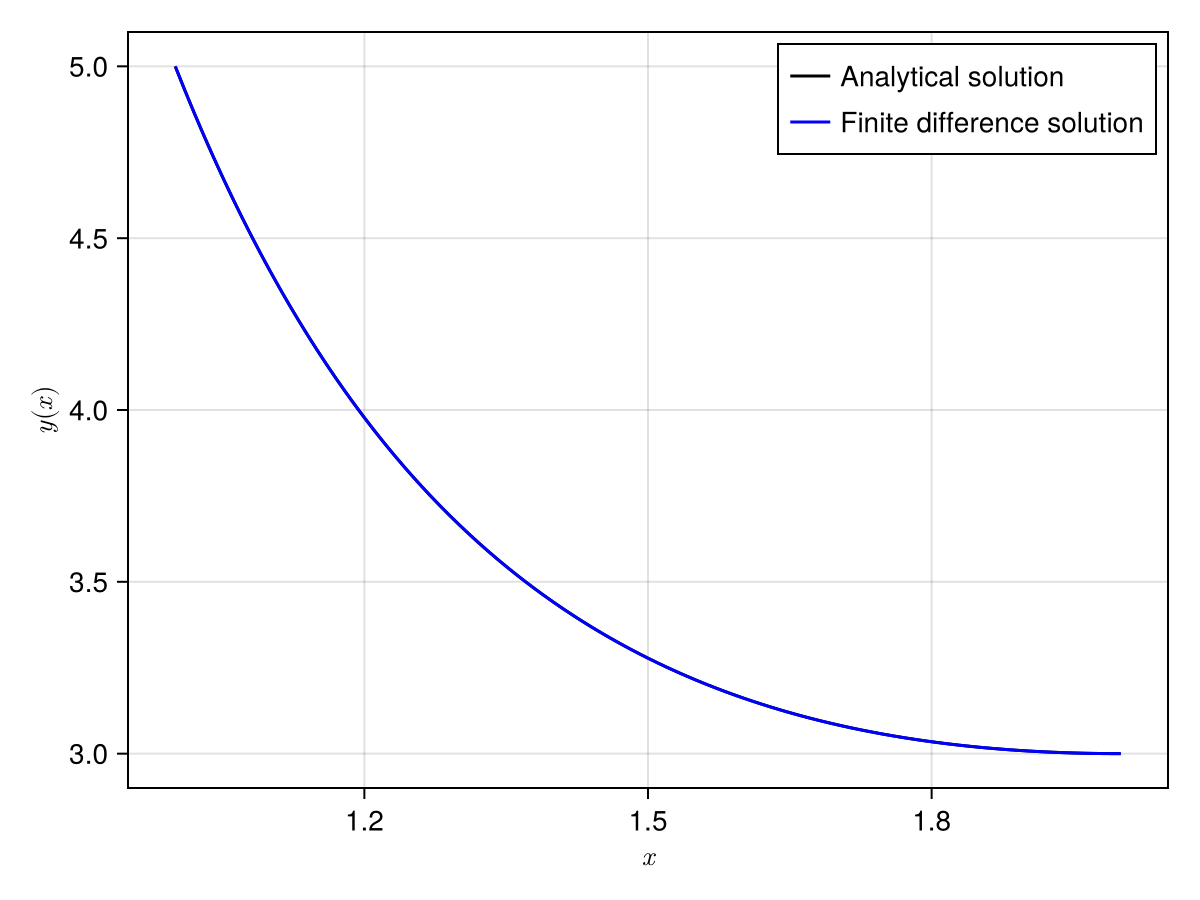

In [21]:
xplot=1:0.01:2
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y(x)")
lines!(ax,xplot,yexact.(xplot),color=:black,label="Analytical solution")
lines!(ax,x,y,color=:blue,label="Finite difference solution")
axislegend(ax,position=:rt)
fig

In [9]:
collect(x)

1001-element Vector{Float64}:
 1.0
 1.001
 1.002
 1.003
 1.004
 1.005
 1.006
 1.007
 1.008
 1.009
 ⋮
 1.992
 1.993
 1.994
 1.995
 1.996
 1.997
 1.998
 1.999
 2.0

It takes a long time to solve this problem.  Much faster to use LinearSolve.jl and tell Julia that you have a sparse matrix

In [10]:
using LinearSolve
using SparseArrays

Define sparse Matrix

In [11]:
ASparse=sparse(A)

1001×1001 SparseMatrixCSC{Float64, Int64} with 2999 stored entries:
⎡⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⎦

In [12]:

probSparse=LinearProblem(ASparse,C)
@time y2=LinearSolve.solve(probSparse, UMFPACKFactorization())

  0.321878 seconds (388.32 k allocations: 21.022 MiB, 65.78% gc time, 99.63% compilation time)


retcode: Success
u: 1001-element Vector{Float64}:
 5.0
 4.993011985357482
 4.986047874983633
 4.979107573594945
 4.972190986382188
 4.965298019007587
 4.95842857760201
 4.951582568762174
 4.944759899547878
 4.937960477479248
 ⋮
 3.000048258945858
 3.000036923705416
 3.0000271096507376
 3.000018813732591
 3.000012032909381
 3.0000067641471255
 3.000003004419435
 3.0000007507074864
 3.0

Note the time taken to solve the system using \  and using LinearSolve with sparse matrix definition.  The gap gets bigger as you use larger number of grid points